# Regresión Lineal Simple

### Suposiciones

* Relación lineal.
* Normalidad.
* No multicolinealidad.
* No auto-correlación.
* Varianzas iguales.

### Contexto y Datos

In [2]:
import pandas as pd

datos = pd.read_csv("ingreso.csv")
datos

,ingreso,horas
0,9973.577534,40.905476
1,8961.047249,41.576483
2,7437.977263,41.369239
3,12064.915290,41.537211
4,9296.396167,40.441203
...,...,...
995,9998.522402,41.110352
996,6867.097603,40.617061
997,9757.539280,40.798085
998,11044.031510,41.443604


### Gráficar Datos

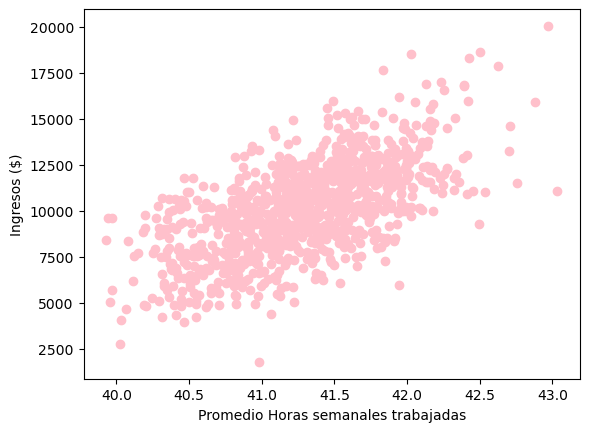

In [3]:
import matplotlib.pyplot as plt

plt.ylabel("Ingresos ($)")
plt.xlabel("Promedio Horas semanales trabajadas")
plt.scatter(datos["horas"], datos["ingreso"], color="pink")
plt.show()

### Creación del Modelo de Regresión Lineal Simple

* La intersección representa el corte de y.
* El coef, es la razón o pendiente, es decir que en promedio cada una persona estaría ganando $3000 pesos.
* Según el modelo una persona que trabaja 39 horas ganará 3328 por hora. El de 50 serán 6294.

Intersección(b):  -112320.22713310868
Pendiente (m):  [2965.35614382]


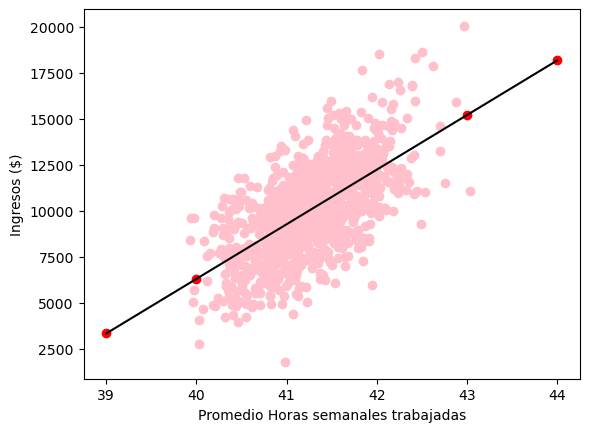

In [9]:
from sklearn import linear_model

regresion = linear_model.LinearRegression()
horas = datos["horas"].values.reshape((-1,1))
modelo = regresion.fit(horas, datos["ingreso"])
print("Intersección(b): ", modelo.intercept_)
print("Pendiente (m): ", modelo.coef_)

# Ahora hagamos unas predicciones sobre horas
entrada = [[39],[40],[43], [44]]
modelo.predict(entrada)

# Graficar la linea
plt.scatter(entrada, modelo.predict(entrada), color="red")
plt.plot(entrada, modelo.predict(entrada), color="black")
plt.ylabel("Ingresos ($)")
plt.xlabel("Promedio Horas semanales trabajadas")
plt.scatter(datos["horas"], datos["ingreso"], color="pink")
plt.show()



# Machine Learning

### Datos para Entrenamiento, Validación y Prueba.

* General un conjunto de datos es separados en 3, datos para entrenamiento, validación y prueba.
* Esto se hace ya que si el modelo conoce todas las respuestas, pudo haber memorizado o guardado un respuesta para un valor determinado.
* El conjunto más grande es el de entrenamiento, por otro lado lo de prueba no son tan grandes, una caracterisitcas de esos 2 es que deben ser mutuamente excluyentes.
* Con esto, nos ayuda a calificar que buen rendimiento tendrá nuestro modelo.
* No existe los modelos del 100%.
* Existe un tercero, que es el conjunto de Validación.

### Separción de Datos

### 60% Entrenamiento, 20% Validación y 20% Prueba

* `train_test_split`:nos regresa 4 conjuntos de datos, los de pruebas también nos regresa las clases de pruebas.
* Los indices dentro de resto está Aleatorizado.

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

pacientes = pd.read_csv("problemas_del_corazon.csv")
resto, prueba, resto_clase, prueba_clase = train_test_split(
    pacientes[["edad","genero","presion","colesterol","diabetico"]],
    pacientes["cardiaco"],
    test_size= 0.20
)

# Del resto, sacamos los datos de validación
resto, valida, resto_clase, prueba_clase = train_test_split(
    resto[["edad","genero","presion","colesterol","diabetico"]],
    resto_clase,
    test_size= 0.20
)
valida.shape[0]

16